# 6 — The two stages together, and the demo

Notebooks 4 and 5 measured each stage on its own. Stage 2 in particular was scored on
**gold ADE sentences** — as though Stage 1 were perfect.

It is not. This notebook chains the two and measures what that assumption costs:

```
      sentence
         |
    [ Stage 1 gate ]  --- "not an ADE" --->  no entities, done
         |
      "ADE"
         |
    [ Stage 2 tagger ]  --->  DRUG and EFFECT spans
```

The gate makes two kinds of mistake, and they do different damage:

- **a miss** — a real ADE sentence rejected. Stage 2 never sees it, so its entities are
  lost and nothing downstream can recover them.
- **a false alarm** — a non-ADE sentence passed through. Stage 2 tags it anyway, inventing
  entities that should not exist.

In [1]:
import sys, json, textwrap
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import pandas as pd
pd.set_option("display.max_colwidth", 90)
print("project root:", ROOT)

project root: E:\CSE\NLP Project


---

## 6.1 Setting up the measurement

Both stages are scored over the **same 3,133-sentence Stage 1 test split**, holding all
1,612 gold entities. That only works because both stages share one split (notebook 1) — a
sentence with no annotation is a sentence whose correct answer is "no entities", which is
exactly what a gate rejection should produce.

In [2]:
from src.bio import entity_prf, strict_entities, to_bio
from src.vocab import is_indexable

stage1_test = pd.read_parquet(ROOT / "data" / "splits" / "stage1_test.parquet")
stage2_test = pd.read_parquet(ROOT / "data" / "splits" / "stage2_test.parquet")

spans_by_text = {r["text"]: json.loads(r["spans"]) for _, r in stage2_test.iterrows()}

words, gold = [], []
for text in stage1_test["text"]:
    tokens, tags = to_bio(text, [tuple(s) for s in spans_by_text.get(text, [])], strict=False)
    kept = [(t, g) for t, g in zip(tokens, tags) if is_indexable(t)]
    words.append([t for t, _ in kept])
    gold.append(strict_entities([g for _, g in kept]))

print(f"{len(stage1_test):,} test sentences")
print(f"{sum(bool(g) for g in gold):,} of them carry annotations")
print(f"{sum(len(g) for g in gold):,} gold entities in total")

3,133 test sentences
640 of them carry annotations
1,612 gold entities in total


---

## 6.2 What the gate does

Using run 6, the BiLSTM gate the demo loads by default.

In [3]:
import time
from src.pipeline import load_gate, load_tagger

t0 = time.perf_counter()
gate = load_gate("6")
decisions = gate.classify(stage1_test["text"].tolist())
accepted = [i for i, (_, is_ade) in enumerate(decisions) if is_ade]
print(f"gate ran over {len(stage1_test):,} sentences in {time.perf_counter() - t0:.1f}s\n")

truth = stage1_test["label"].tolist()
passed = [bool(is_ade) for _, is_ade in decisions]

confusion = pd.DataFrame(
    [[sum(1 for t, p in zip(truth, passed) if t == 1 and p),
      sum(1 for t, p in zip(truth, passed) if t == 1 and not p)],
     [sum(1 for t, p in zip(truth, passed) if t == 0 and p),
      sum(1 for t, p in zip(truth, passed) if t == 0 and not p)]],
    index=["really an ADE", "really not an ADE"],
    columns=["gate says ADE", "gate says not-ADE"])
display(confusion)

kept_ade = confusion.iloc[0, 0]
print(f"\n{len(accepted):,} sentences reach Stage 2.")
print(f"  {kept_ade} are real ADEs  -> recall {kept_ade / sum(truth):.1%}")
print(f"  {len(accepted) - kept_ade} are not -> precision {kept_ade / len(accepted):.1%}")
print(f"  {confusion.iloc[0, 1]} real ADEs were rejected and can never be recovered.")

gate ran over 3,133 sentences in 6.1s



,gate says ADE,gate says not-ADE
really an ADE,521,119
really not an ADE,130,2363



651 sentences reach Stage 2.
  521 are real ADEs  -> recall 81.4%
  130 are not -> precision 80.0%
  119 real ADEs were rejected and can never be recovered.


---

## 6.3 Oracle vs pipeline

Now the same tagger is scored twice over the same 3,133 sentences:

- **oracle** — it is handed every gold ADE sentence, the setting notebook 5 used;
- **pipeline** — the gate decides what it sees, which is the realistic setting.

In [4]:
tagger = load_tagger("10")

# Pipeline: only the sentences the gate accepted.
tagged = dict(zip(accepted, tagger.tag([words[i] for i in accepted])))
pipeline_pred = [strict_entities(tagged[i]) if i in tagged else [] for i in range(len(words))]

# Oracle: every sentence that really is an ADE, whatever the gate thought.
positives = [i for i in range(len(words)) if gold[i]]
otagged = dict(zip(positives, tagger.tag([words[i] for i in positives])))
oracle_pred = [strict_entities(otagged[i]) if i in otagged else [] for i in range(len(words))]

rows = []
for setting, predicted in [("oracle (Stage 1 assumed perfect)", oracle_pred),
                           ("pipeline (Stage 1 decides)", pipeline_pred)]:
    precision, recall, f1 = entity_prf(gold, predicted)
    rows.append({"setting": setting, "strict entity-F1": round(f1, 4),
                 "precision": round(precision, 3), "recall": round(recall, 3),
                 "entities predicted": sum(len(p) for p in predicted)})

comparison = pd.DataFrame(rows).set_index("setting")
display(comparison)

drop = comparison["strict entity-F1"].iloc[0] - comparison["strict entity-F1"].iloc[1]
print(f"\nerror propagation cost: -{drop:.4f} entity-F1")

,strict entity-F1,precision,recall,entities predicted
setting,,,,
oracle (Stage 1 assumed perfect),0.8308,0.854,0.809,1527
pipeline (Stage 1 decides),0.6891,0.699,0.680,1569



error propagation cost: -0.1417 entity-F1


**0.8308 → 0.6891.** A tagger that looks like it gets five entities in six right delivers
roughly two in three once a real classifier decides what it sees.

That gap *is* the finding. It is not a flaw in either model — each one performs exactly as
measured. It is what happens when two imperfect stages are chained, and it is invisible if
you only ever report per-stage scores.

Look at which side moves: precision falls from 0.854 to 0.699 and recall from 0.809 to
0.680. Both suffer, for the two different reasons named at the top — rejected ADE sentences
cost recall, and wrongly accepted ones cost precision by producing entities out of nothing.

### The same measurement for the stronger pair

Run 12 chains the two best models, BiomedBERT gate (run 8) and BiomedBERT tagger (run 11).
Those are read from the run log rather than recomputed here, because they take minutes on a
CPU rather than seconds.

| Pair | Oracle | Pipeline | Cost |
|---|---|---|---|
| run 6 + run 10 (BiLSTM, the demo default) | 0.8308 | **0.6891** | -0.1417 |
| run 8 + run 11 (BiomedBERT, run 12) | 0.9052 | **0.8334** | -0.0718 |

The better gate loses about half as much. Its recall is 93.8% against the BiLSTM's 81.4%,
so far fewer ADE sentences are thrown away before the tagger ever sees them.

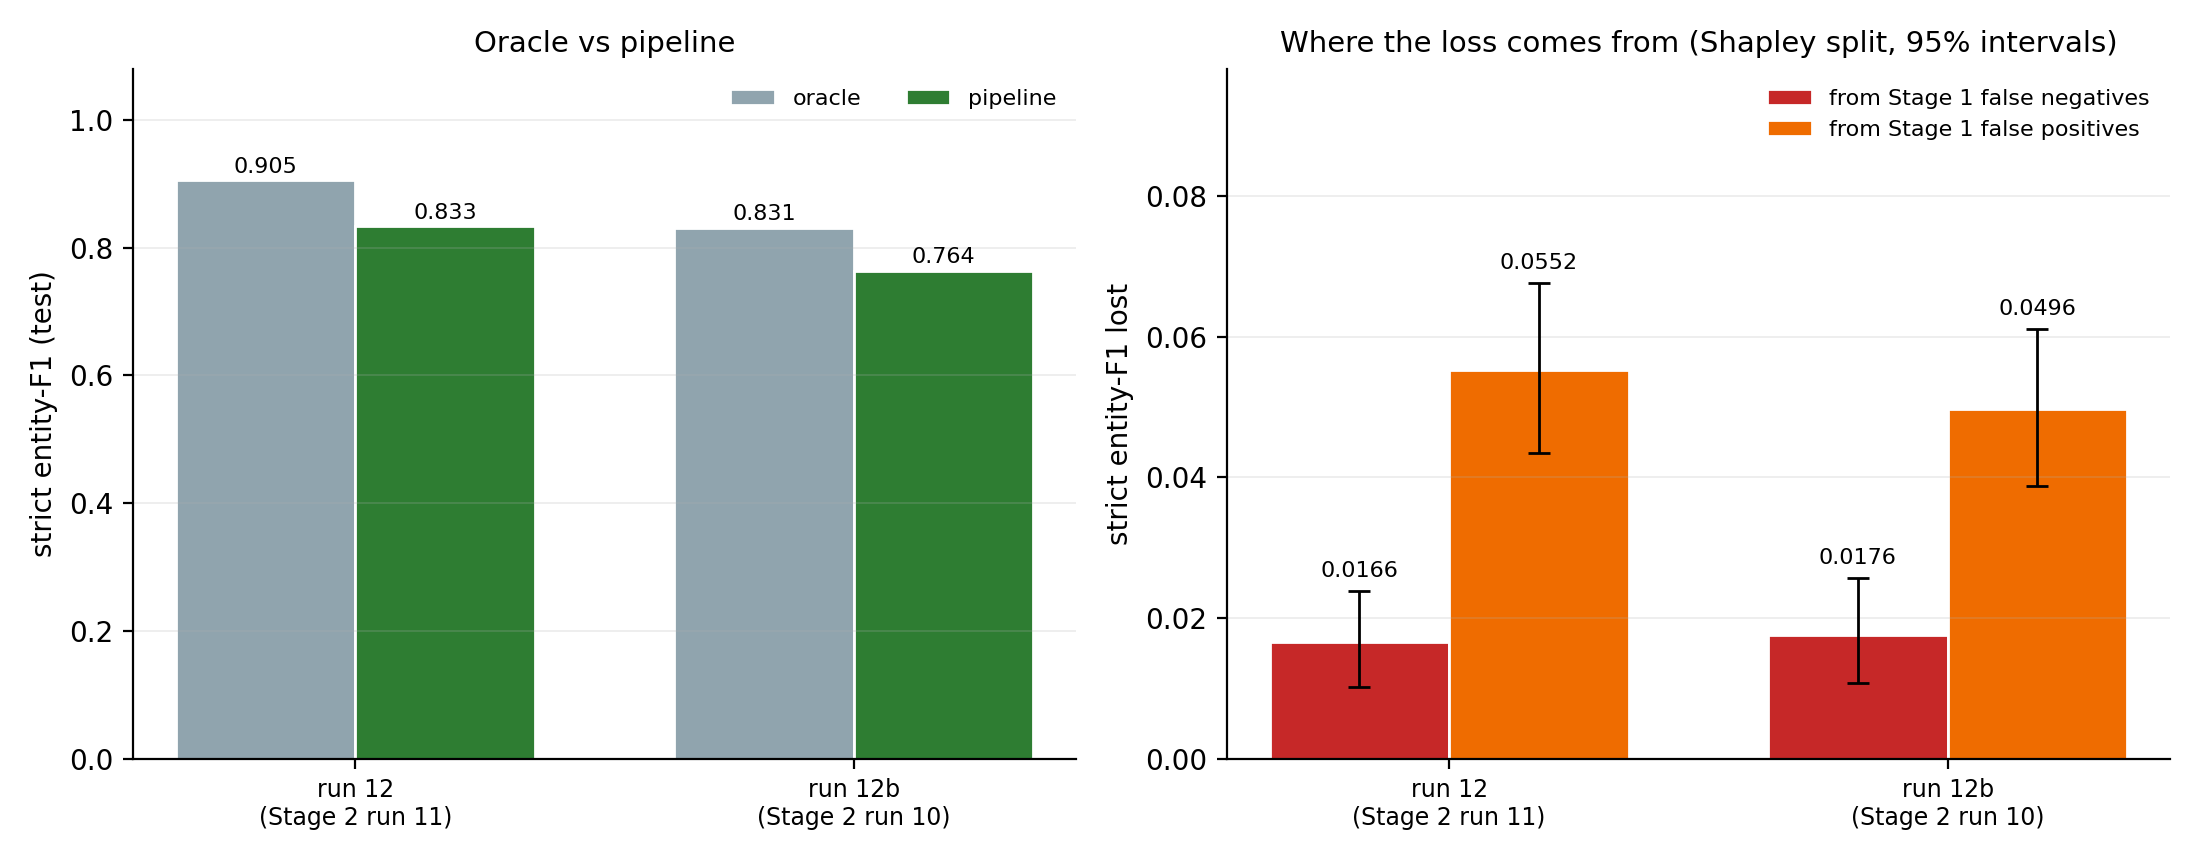

In [5]:
from IPython.display import Image
Image(filename=str(ROOT / "results" / "figures" / "pipeline_loss.png"))

---

## 6.4 Where the models struggle: negation and hedging

A sentence can name a drug and a side effect and still not report an adverse event:

> *"The patient was then treated with sertraline **without** experiencing any incontinence
> episodes."*

Both entities are there. The relation between them is negated. Getting this wrong is not a
small error — it inverts the meaning.

To measure it, 615 test sentences containing a negation or hedging cue were selected **by
rule, from the sentence text alone** — no label and no prediction chose a sentence — and
frozen. That makes it a measurement rather than a collection of anecdotes.

| Group | Sentences | ADE rate |
|---|---|---|
| full test split | 3,133 | 20.4% |
| contains a negation cue (`not`, `no`, `without`, `failed to`, `ruled out`, ...) | 272 | 9.2% |
| contains a hedging cue (`may`, `suggest`, `possible`, `could`, ...) | 382 | 24.6% |
| **either — the challenge subset** | **615** | 19.0% |
| neither | 2,518 | 20.8% |

The ADE rate is similar with cues (19.0%) and without (20.8%), so a score difference
between the groups is not just a difference in class balance.

In [6]:
runs = pd.read_csv(ROOT / "results" / "runs.csv").drop_duplicates("run_id", keep="last")
runs = runs.set_index("run_id")

LADDER = {"1": "Naive Bayes", "2": "Logistic Regression", "3": "BiLSTM + E0 random",
          "4": "BiLSTM + E1 GloVe", "5": "BiLSTM + E2 Word2Vec", "6": "BiLSTM + E3 FastText",
          "7": "BERT base", "8": "BiomedBERT"}

rows = []
for run, name in LADDER.items():
    m = json.loads(runs.loc[f"13-{run}", "metrics_json"])
    low, high = m["ci95_cue_minus_no_cue_macro_f1"]
    rows.append({"model": name,
                 "full split": round(m["full_macro_f1"], 4),
                 "with a cue": round(m["cue_macro_f1"], 4),
                 "no cue": round(m["no_cue_macro_f1"], 4),
                 "cue - no cue": round(m["cue_minus_no_cue_macro_f1"], 4),
                 "95% interval": f"[{low:+.3f}, {high:+.3f}]"})

pd.DataFrame(rows).set_index("model")

,full split,with a cue,no cue,cue - no cue,95% interval
model,,,,,
Naive Bayes,0.7678,0.7417,0.7724,-0.0307,"[-0.081, +0.018]"
Logistic Regression,0.7934,0.7563,0.8014,-0.0451,"[-0.096, +0.001]"
BiLSTM + E0 random,0.7441,0.6711,0.7579,-0.0869,"[-0.140, -0.037]"
BiLSTM + E1 GloVe,0.7942,0.7676,0.8003,-0.0328,"[-0.080, +0.010]"
BiLSTM + E2 Word2Vec,0.8609,0.8254,0.8691,-0.0437,"[-0.086, -0.004]"
BiLSTM + E3 FastText,0.8785,0.8584,0.8831,-0.0247,"[-0.064, +0.013]"
BERT base,0.9159,0.8958,0.9205,-0.0247,"[-0.060, +0.009]"
BiomedBERT,0.9402,0.9205,0.9447,-0.0242,"[-0.055, +0.004]"


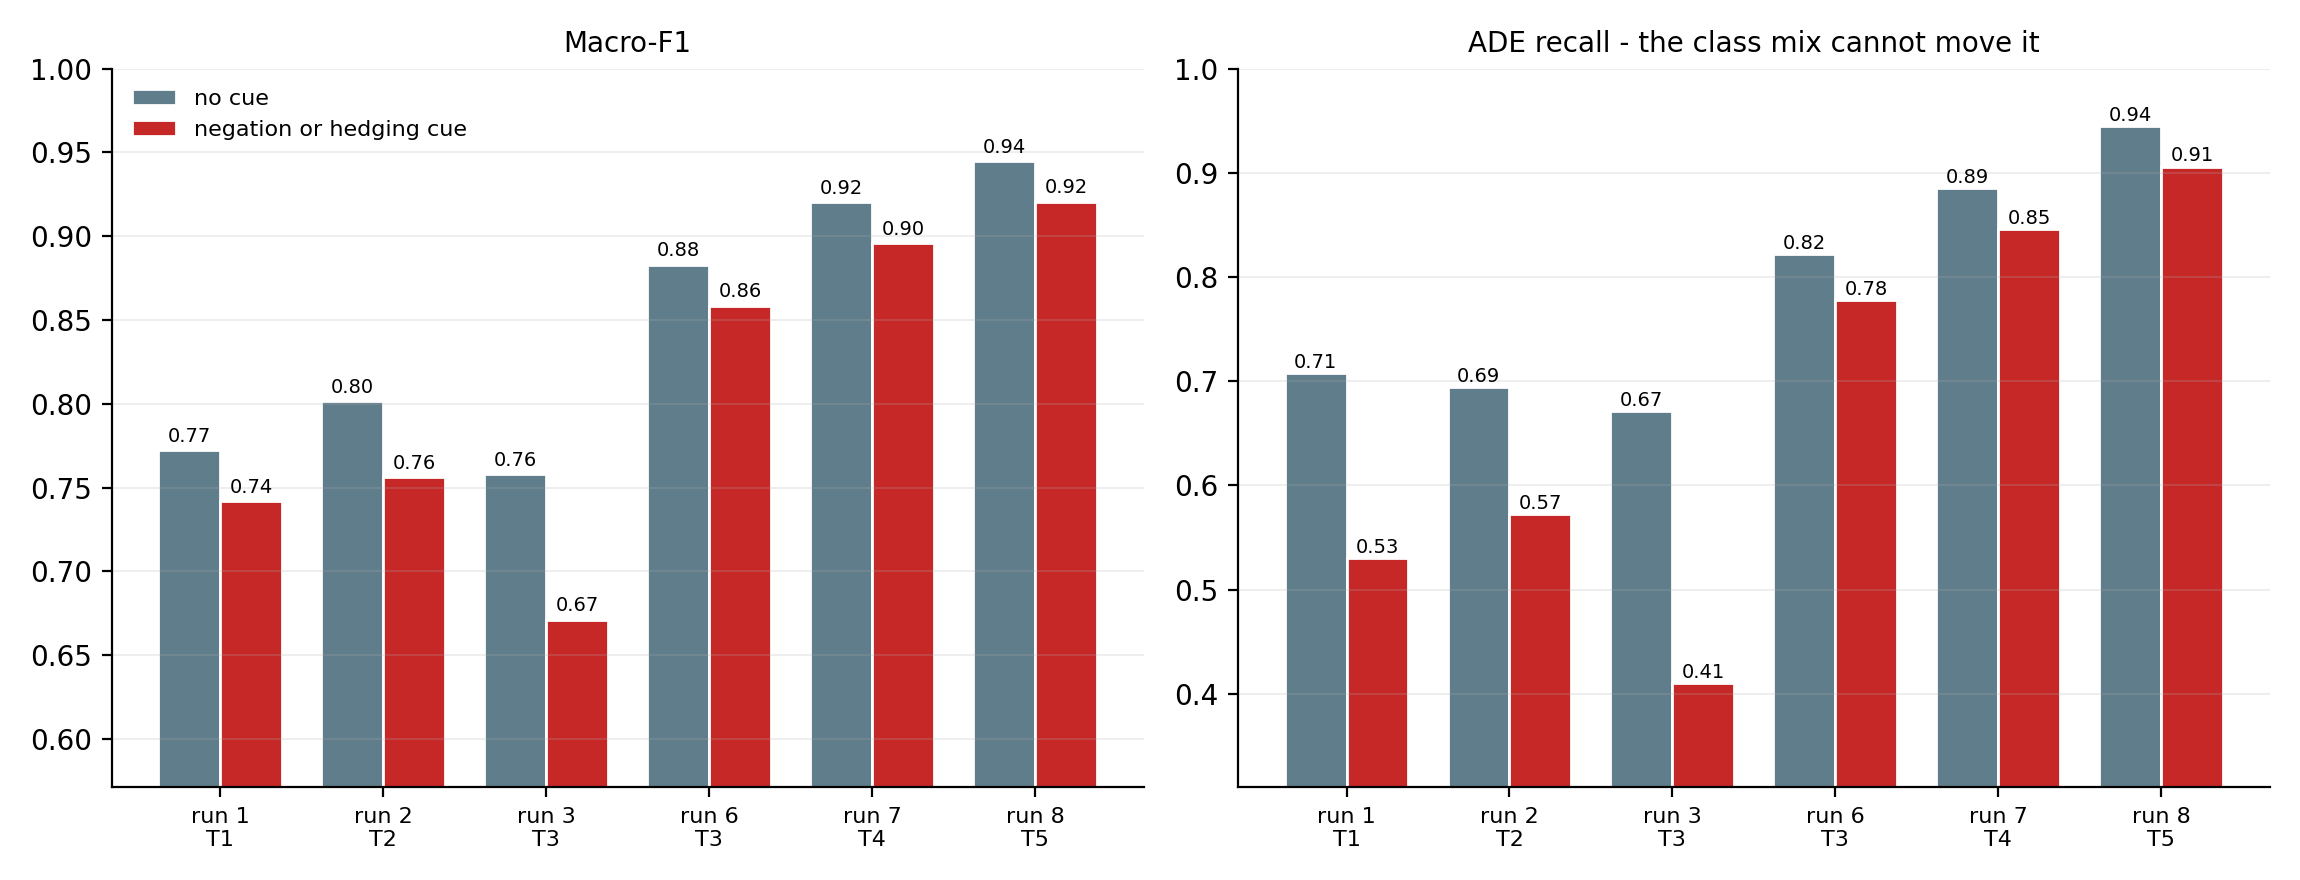

In [7]:
Image(filename=str(ROOT / "results" / "figures" / "negation_ladder.png"))

**Every single model does worse on sentences containing a cue.** The `cue - no cue` column
is negative all the way down the ladder, from Naive Bayes to BiomedBERT. The intervals are
95% bootstrap intervals for that difference, with each group resampled independently.

But notice how the size of the gap moves. It does not shrink smoothly as the models get
better — BiomedBERT's -0.024 is about the same as Naive Bayes's -0.031, while the weakest
BiLSTM is worst at -0.087. Scaling the model up raises the whole curve rather than closing
this particular gap.

Most of the intervals cross zero, so no single row here is conclusive on its own. What is
convincing is that **all eight point the same way** — that consistency, not any one
model's number, is the evidence.

So negation is not simply "a hard case that better models solve". It is a *structural*
difficulty: the cue word is often far from the drug-effect pair it applies to, and whether
it negates that relation or something else entirely is the whole question. Compare the two
examples the demo ships:

- *"...treated with sertraline **without** experiencing any incontinence episodes."* —
  `without` negates the relation. **Not an ADE.**
- *"A 53-year-old male, **without** any prior history of psychosis, developed
  schizophrenia 4 days after starting bromocriptine."* — `without` negates the patient's
  history, not the relation. **Still an ADE.**

Same cue word, opposite answers.

### Where the pipeline's failures actually are

269 of the 3,133 test sentences come out wrong end to end (using the run 12 pair). Broken
down by what went wrong:

| Error kind | Sentences | Share |
|---|---|---|
| gate false alarm — a non-ADE passed through and got tagged | 85 | 31.6% |
| boundary — right entity, wrong extent | 60 | 22.3% |
| spurious entity | 50 | 18.6% |
| missed entity | 42 | 15.6% |
| gate miss — a real ADE rejected | 40 | 14.9% |
| wrong label — DRUG marked as EFFECT or the reverse | 9 | 3.3% |

**Nearly half of all failures are the gate's**, not the tagger's — 125 of 269 sentences
never had a chance. That is the same conclusion the oracle-vs-pipeline gap reached, arriving
from a different direction, and it is where effort would go next.

Each sentence property was also tested against the failure rate with Fisher's exact test
(10 tests, Bonferroni threshold p < 0.005). Only one difference cleared the bar: among
sentences the gate passed, those containing a **hedging cue** fail Stage 2 more often —
22.2% vs 11.8%, p = 0.004. Negation cues, multiple drugs and abbreviations showed no
significant effect on their own.

---

## 6.5 The demo

Everything above runs on the frozen test split. The demo runs the same pipeline on **any
text you type**, which is a different problem: nothing has been tokenised, sentence-split
or decoded in advance.

`src/pipeline.py` does that, following the same rules the numbers above were measured
under — argmax for the gate decision, Stage 2 only on accepted sentences, strict entity
reading — so what the demo highlights is what the scorer would have counted.

In [8]:
from src.pipeline import EXAMPLES, load_pipeline

t0 = time.perf_counter()
pipeline = load_pipeline("bilstm")      # run 6 gate + run 10 tagger
print(f"both models loaded in {time.perf_counter() - t0:.1f}s on CPU\n")

for example in EXAMPLES:
    result = pipeline.analyse(example.text)[0]
    verdict = "ADE    " if result.is_ade else "not ADE"
    agrees = "OK" if result.is_ade == example.ade else "WRONG"
    print(f"[{verdict}] confidence {result.confidence:.0%}  ({agrees} - corpus says "
          f"{'ADE' if example.ade else 'not ADE'})")
    print(f"  {example.text}")
    for entity in result.entities:
        print(f"      {entity.label:7s} {entity.text}")
    print()

both models loaded in 0.1s on CPU

[ADE    ] confidence 98%  (OK - corpus says ADE)
  A 55-year-old woman presented an episode of acute urticaria and labial angioedema 60 minutes after ingesting 500 mg of cloxacillin for a skin abscess.
      EFFECT  acute urticaria
      EFFECT  labial angioedema
      DRUG    cloxacillin

[ADE    ] confidence 94%  (OK - corpus says ADE)
  A case of toxic hepatitis caused by combination therapy with methotrexate and etretinate in the treatment of severe psoriasis is presented in a 47-year-old woman.
      EFFECT  toxic hepatitis
      DRUG    methotrexate
      DRUG    etretinate

[not ADE] confidence 94%  (OK - corpus says not ADE)
  The patient was then treated with sertraline without experiencing any incontinence episodes.

[ADE    ] confidence 99%  (OK - corpus says ADE)
  A 53-year-old male, without any prior history of psychosis, developed schizophrenia 4 days after starting low-dose bromocriptine therapy for a macroprolactinoma.
      EFFECT  s

The same five sentences rendered the way the web app shows them — drug in blue, effect in
orange, drawn from the character offsets the tokenizer kept back in notebook 2.

In [9]:
import html as html_lib
from IPython.display import HTML

COLOURS = {"DRUG": "37, 99, 235", "EFFECT": "217, 70, 0"}

def render(result):
    parts, cursor = [], 0
    for entity in result.entities:
        parts.append(html_lib.escape(result.text[cursor:entity.start]))
        rgb = COLOURS[entity.label]
        parts.append(f'<mark style="background: rgba({rgb}, 0.18); '
                     f'border-bottom: 2px solid rgb({rgb}); color: inherit; '
                     f'padding: 0.05em 0.2em; border-radius: 0.25em;">'
                     f'{html_lib.escape(entity.text)}'
                     f'<sup style="font-size:0.6em; font-weight:700; color: rgb({rgb});">'
                     f'{entity.label}</sup></mark>')
        cursor = entity.end
    parts.append(html_lib.escape(result.text[cursor:]))
    badge = ("#b91c1c" if result.is_ade else "#6b7280")
    label = "ADE" if result.is_ade else "not ADE"
    return (f'<div style="margin: 0.9em 0; line-height: 2;">'
            f'<span style="background:{badge}; color:white; padding:0.1em 0.5em; '
            f'border-radius:0.3em; font-size:0.8em;">{label}</span> '
            f'<span style="opacity:0.6; font-size:0.85em;">'
            f'confidence {result.confidence:.0%}</span><br>{"".join(parts)}</div>')

HTML("".join(render(pipeline.analyse(e.text)[0]) for e in EXAMPLES))

Note the third and fifth: the gate rejected them, so Stage 2 never ran and there are no
highlights at all. The tagger on its own would happily have marked `sertraline` and
`incontinence` in the third one — **the gate is what stops it**, and that is the argument
for having two stages rather than one tagger.

### Running the web app

```
.venv\Scripts\python -m streamlit run app\streamlit_app.py
```

It opens at <http://localhost:8501>. Type or paste any text; each sentence is judged
separately. The sidebar switches between the two model pairs — the BiLSTM pair loads in
about two seconds, the BiomedBERT pair takes longer but is the more accurate one.

`app/HOW_TO_TEST.md` is a walkthrough written for someone who has never seen the project.

---

## What this notebook showed

| Question | Answer |
|---|---|
| What does chaining the stages cost? | 0.8308 → **0.6891** entity-F1 (BiLSTM pair) |
| Does a better gate help? | yes — run 12's cost is half as large, -0.072 vs -0.142 |
| Whose fault are the failures? | **125 of 269 are the gate's**, not the tagger's |
| Are negated sentences harder? | yes, for **every** model, and scale does not fix it |
| Does it work on new text? | yes — `app/streamlit_app.py`, both stages on CPU |

---

### The project in five numbers

| | |
|---|---|
| embedding ablation, Stage 1 macro-F1 | 0.744 (random) → **0.879** (our FastText) |
| best Stage 1 model | BiomedBERT, **0.940** macro-F1 |
| best Stage 2 tagger | BiomedBERT, **0.905** strict entity-F1 |
| CRF effect on malformed tag sequences | 82 → **5** |
| end to end, both stages chained | **0.833** strict entity-F1 |

The first row is the one the project set out to produce: **word vectors trained on 159,975
PubMed abstracts beat general-purpose English vectors by 0.084 macro-F1** — more than the
gain from having pretrained vectors at all.